In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# 4. Pipeline with PCA
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", DecisionTreeClassifier(random_state=42))
])

In [9]:
param_grid = {
    "pca__n_components": [5, 10, 15, 20],   # correct step name
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [3, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV (Accuracy only)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    refit=True,
    n_jobs=-1
)
grid.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__criterion': ['gini', 'entropy', ...], 'clf__max_depth': [3, 5, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [11]:
# Collect results
dt_results = pd.DataFrame(grid.cv_results_)

# Keep all hyperparameters + accuracy
dt_table = dt_results[[
    "param_clf__criterion",
    "param_clf__max_depth",
    "param_clf__min_samples_split",
    "param_clf__min_samples_leaf",
    "mean_test_score"
]].rename(columns={
    "param_clf__criterion": "criterion",
    "param_clf__max_depth": "max_depth",
    "param_clf__min_samples_split": "min_samples_split",
    "param_clf__min_samples_leaf": "min_samples_leaf",
    "mean_test_score": "Accuracy"
})

# Top 5
top5 = dt_table.sort_values(by="Accuracy", ascending=False).head(5)
print("\nTop 5 Results (by Accuracy):")
print(top5)



Top 5 Results (by Accuracy):
   criterion  max_depth  min_samples_split  min_samples_leaf  Accuracy
44      gini          5                 10                 1  0.940659
80      gini         10                 10                 1  0.938462
40      gini          5                  5                 1  0.936264
56      gini          5                 10                 2  0.936264
76      gini         10                  5                 1  0.934066


In [13]:
# Best parameters
best_params = grid.best_params_
best_acc = grid.best_score_
best_table = pd.DataFrame([best_params])
best_table["Best Accuracy"] = best_acc
print("\nBest Hyperparameters:")
print(best_table)


Best Hyperparameters:
  clf__criterion  clf__max_depth  clf__min_samples_leaf  \
0           gini               5                      1   

   clf__min_samples_split  pca__n_components  Best Accuracy  
0                      10                  5       0.940659  


In [17]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))



Test Accuracy: 0.9385964912280702
Test Precision: 0.9487179487179487
Test Recall: 0.8809523809523809
Test F1: 0.9135802469135802
Test ROC AUC: 0.9375


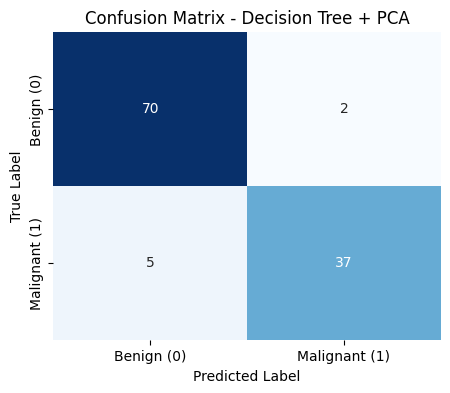

In [34]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benign (0)", "Malignant (1)"],
            yticklabels=["Benign (0)", "Malignant (1)"])
plt.title("Confusion Matrix - Decision Tree + PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

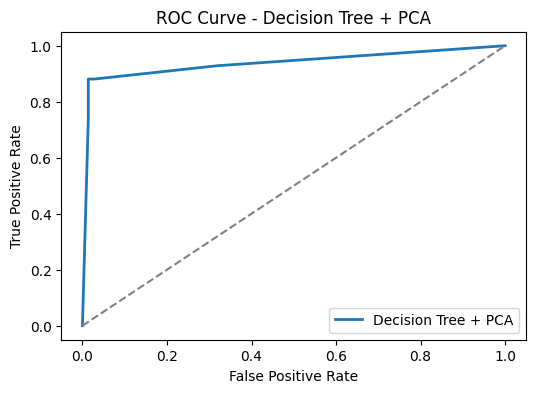

In [43]:
# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Decision Tree + PCA", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree + PCA")
plt.legend()
plt.show()

In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Best Decision Tree with tuned hyperparameters
best_dt = DecisionTreeClassifier(
    criterion=grid.best_params_['clf__criterion'],
    max_depth=grid.best_params_['clf__max_depth'],
    min_samples_split=grid.best_params_['clf__min_samples_split'],
    min_samples_leaf=grid.best_params_['clf__min_samples_leaf'],
    random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", best_dt)
])

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(pipe_cv, X, y, cv=cv, scoring="accuracy")

# Print each fold's accuracy
for i, acc in enumerate(cv_accuracy, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")

# Print average accuracy
print(f"Average 5-Fold CV Accuracy: {cv_accuracy.mean():.4f}")

Fold 1 Accuracy: 0.9737
Fold 2 Accuracy: 0.9298
Fold 3 Accuracy: 0.8947
Fold 4 Accuracy: 0.9123
Fold 5 Accuracy: 0.9646
Average 5-Fold CV Accuracy: 0.9350
